# Theo Analysis - Round 1

Goal: Develop better theoretical fair values for **ASH_COATED_OSMIUM** and **INTARIAN_PEPPER_ROOT** to support market making.

Current theos:
- ASH: fixed at 10,000
- PEPPER: linear drift `anchor + (t - t0) * 0.001`

## 0. Setup & Data Loading

In [33]:
import os, glob as gl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 120, 'axes.grid': False, 'grid.alpha': 0.3})

In [2]:
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "data")
# Adjust path if running from research/
if not os.path.isdir(DATA_DIR):
    DATA_DIR = os.path.join(os.path.abspath("."), "round-1", "data")
if not os.path.isdir(DATA_DIR):
    DATA_DIR = os.path.join(os.path.abspath(".."), "data")

print(f"Data dir: {DATA_DIR}")

Data dir: C:\Users\minse\OneDrive\Desktop\prosperity\imc-prosperity-4-quantsc\round-1\data


In [59]:
# Load prices
price_files = sorted(gl.glob(os.path.join(DATA_DIR, "prices_round_1_day_*.csv")))
prices = pd.concat([pd.read_csv(f, sep=";") for f in price_files], ignore_index=True)
prices.sort_values(["day", "timestamp"], inplace=True)

# Override mid_price with two-sided mid (only keep rows where both best bid and best ask exist)
prices = prices[prices["bid_price_1"].notna() & prices["ask_price_1"].notna()].copy()
prices["mid_price"] = (prices["bid_price_1"] + prices["ask_price_1"]) / 2

# Continuous time index
DAY_LEN = 1_000_000
prices["time"] = (prices["day"] - prices["day"].min()) * DAY_LEN + prices["timestamp"]

# Load trades
trade_files = sorted(gl.glob(os.path.join(DATA_DIR, "trades_round_1_day_*.csv")))
trades = pd.concat([pd.read_csv(f, sep=";") for f in trade_files], ignore_index=True)

# Infer day from filename
trade_dfs = []
for f in trade_files:
    tdf = pd.read_csv(f, sep=";")
    day_str = f.split("day_")[1].replace(".csv", "")
    tdf["day"] = int(day_str)
    trade_dfs.append(tdf)
trades = pd.concat(trade_dfs, ignore_index=True)
trades.sort_values(["day", "timestamp"], inplace=True)
trades["time"] = (trades["day"] - trades["day"].min()) * DAY_LEN + trades["timestamp"]

# Split by product
aco = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy().reset_index(drop=True)
ipr = prices[prices["product"] == "INTARIAN_PEPPER_ROOT"].copy().reset_index(drop=True)

aco["spread"] = aco["ask_price_1"] - aco["bid_price_1"]
ipr["spread"] = ipr["ask_price_1"] - ipr["bid_price_1"]
aco["ret"] = aco["mid_price"].diff()
ipr["ret"] = ipr["mid_price"].diff()

aco_trades = trades[trades["symbol"] == "ASH_COATED_OSMIUM"].copy().reset_index(drop=True)
ipr_trades = trades[trades["symbol"] == "INTARIAN_PEPPER_ROOT"].copy().reset_index(drop=True)

print(f"ASH prices: {len(aco)}, PEPPER prices: {len(ipr)}")
print(f"ASH trades: {len(aco_trades)}, PEPPER trades: {len(ipr_trades)}")
print(f"Days: {sorted(prices['day'].unique())}")

ASH prices: 27644, PEPPER prices: 27688
ASH trades: 1265, PEPPER trades: 1011
Days: [-2, -1, 0]


## 1. ASH EDA & Theo

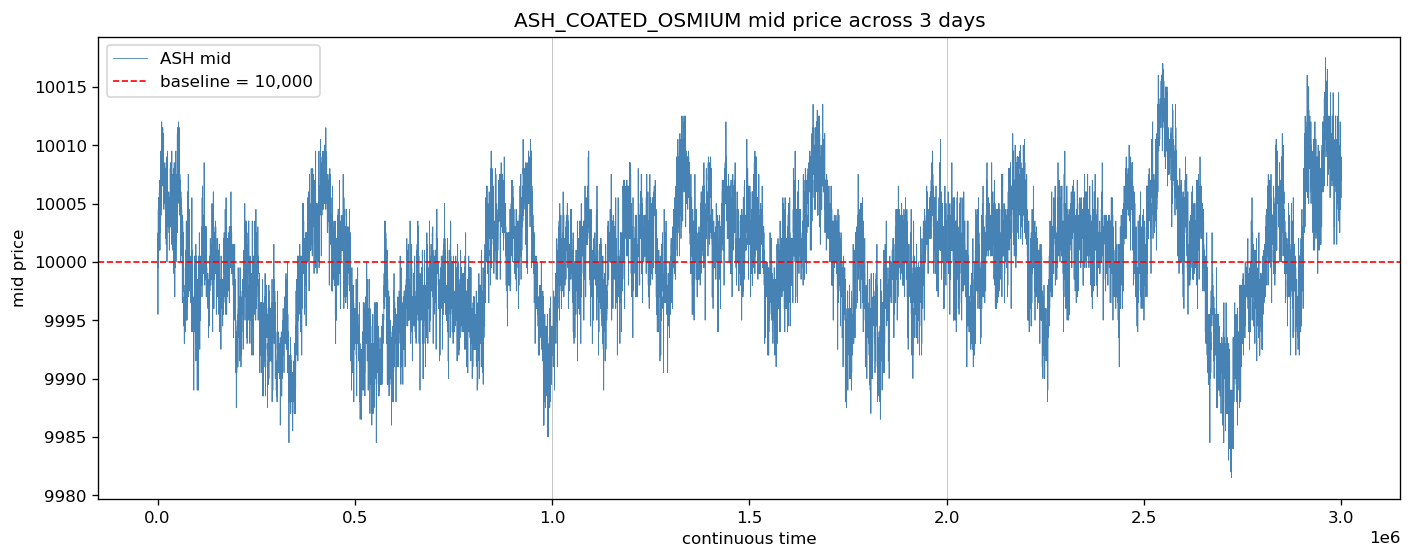

In [60]:
# 1.1 Price series with 10,000 overlay
fig, ax = plt.subplots()
ax.plot(aco["time"], aco["mid_price"], lw=0.5, color="steelblue", label="ASH mid")
ax.axhline(10_000, color="red", lw=1, ls="--", label="baseline = 10,000")
for k in range(1, len(aco["day"].unique())):
    ax.axvline(k * DAY_LEN, color="gray", lw=0.5, alpha=0.5)
ax.set_title("ASH_COATED_OSMIUM mid price across 3 days")
ax.set_xlabel("continuous time")
ax.set_ylabel("mid price")
ax.legend()
plt.show()

In [61]:
# 1.2 Per-day and overall mean / median / std
per_day = aco.groupby("day")["mid_price"].agg(["mean", "median", "std", "min", "max", "count"])
overall = aco["mid_price"].agg(["mean", "median", "std", "min", "max", "count"]).to_frame("overall").T
print(per_day)
print()
print(overall)

             mean   median       std     min      max  count
day                                                         
-2    9998.161750   9998.0  4.726266  9984.5  10012.0   9187
-1   10000.833550  10001.0  3.825387  9986.5  10013.5   9225
 0   10001.622563  10002.0  5.221837  9981.5  10017.5   9232

                 mean   median       std     min      max    count
overall  10000.209123  10000.5  4.858191  9981.5  10017.5  27644.0


In [62]:
# 1.3 VWAP from trades vs mid mean per day
vwap = aco_trades.groupby("day").apply(lambda d: (d["price"] * d["quantity"]).sum() / d["quantity"].sum()).rename("vwap")
mid_mean = aco.groupby("day")["mid_price"].mean().rename("mid_mean")
cmp = pd.concat([vwap, mid_mean], axis=1)
cmp["vwap - mid_mean"] = cmp["vwap"] - cmp["mid_mean"]
cmp["vwap - 10000"] = cmp["vwap"] - 10_000
print(cmp)

             vwap      mid_mean  vwap - mid_mean  vwap - 10000
day                                                           
-2    9998.262896   9998.161750         0.101146     -1.737104
-1   10000.846742  10000.833550         0.013191      0.846742
 0   10001.644578  10001.622563         0.022015      1.644578


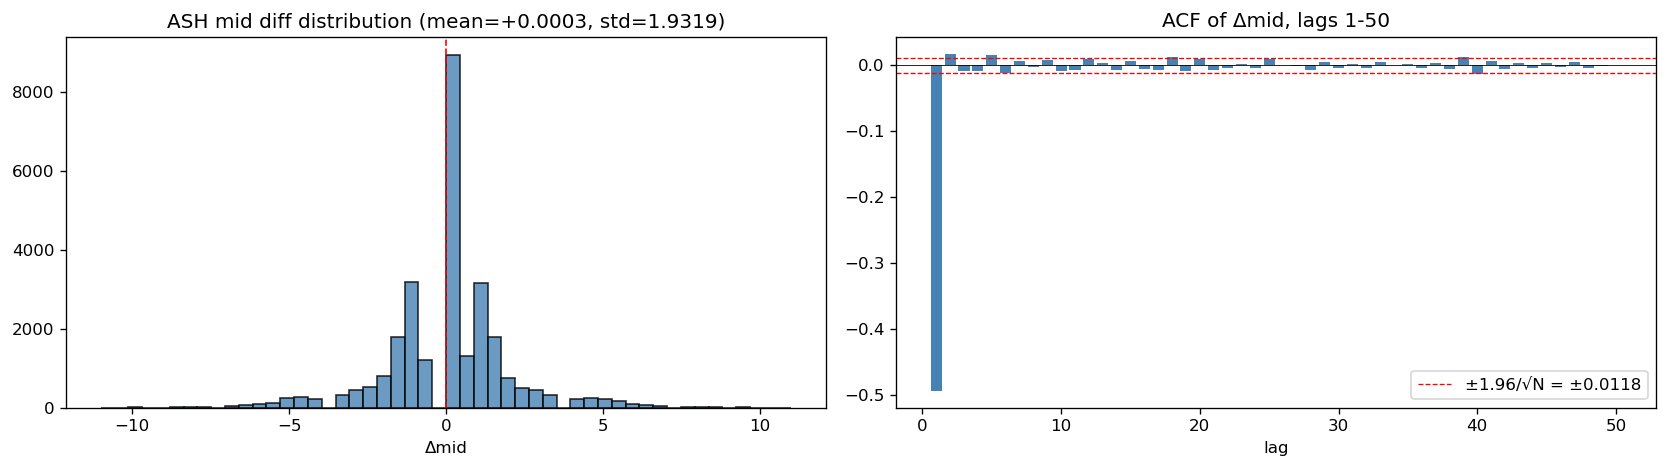

Lag-1 ACF: -0.4944  [negative ⇒ mean-reverting (likely due to bid-ask bounce), positive ⇒ momentum]


In [64]:
# 1.4 Mid-diff distribution + ACF (lags 1-50)
r = aco["ret"].dropna()
n = len(r)
ci = 1.96 / np.sqrt(n)
acf_vals = acf(r, nlags=50, fft=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(r, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title(f"ASH mid diff distribution (mean={r.mean():+.4f}, std={r.std():.4f})")
axes[0].set_xlabel("Δmid")
axes[0].axvline(0, color="red", lw=1, ls="--")

lags = np.arange(1, 51)
axes[1].bar(lags, acf_vals[1:], color="steelblue")
axes[1].axhline(ci, color="red", lw=0.8, ls="--", label=f"±1.96/√N = ±{ci:.4f}")
axes[1].axhline(-ci, color="red", lw=0.8, ls="--")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("ACF of Δmid, lags 1-50")
axes[1].set_xlabel("lag")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Lag-1 ACF: {acf_vals[1]:+.4f}  [negative ⇒ mean-reverting (likely due to bid-ask bounce), positive ⇒ momentum]")

In [65]:
# 1.5 ADF on (mid - 10000): is the deviation stationary?
dev = aco["mid_price"].values - 10_000
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(dev, autolag="AIC")
print(f"ADF statistic : {adf_stat:.4f}")
print(f"p-value       : {adf_p:.3e}")
print(f"lags used     : {adf_lags}")
print(f"n obs         : {adf_nobs}")
print("critical values:")
for k, v in adf_crit.items():
    print(f"  {k}: {v:.4f}")
print("\n⇒ stationary around 10,000" if adf_p < 0.05 else "\n⇒ NOT stationary at 5% level")

ADF statistic : -5.8505
p-value       : 3.599e-07
lags used     : 17
n obs         : 27626
critical values:
  1%: -3.4306
  5%: -2.8616
  10%: -2.5668

⇒ stationary around 10,000


In [66]:
# 1.6 AR(1) half-life on (mid - 10000)
dev = aco["mid_price"].values - 10_000
y = dev[1:]
x = dev[:-1]
phi, intercept = np.polyfit(x, y, 1)
print(f"phi (AR1 coef) : {phi:+.6f}")
print(f"intercept      : {intercept:+.6f}")

if 0 < phi < 1:
    half_life = -np.log(2) / np.log(phi)
    print(f"half-life      : {half_life:.2f} ticks")
elif -1 < phi < 0:
    print("phi < 0 ⇒ over-shooting / oscillatory mean reversion (no standard half-life)")
else:
    print("phi outside (-1,1) ⇒ non-stationary; half-life undefined")

phi (AR1 coef) : +0.920970
intercept      : +0.016761
half-life      : 8.42 ticks


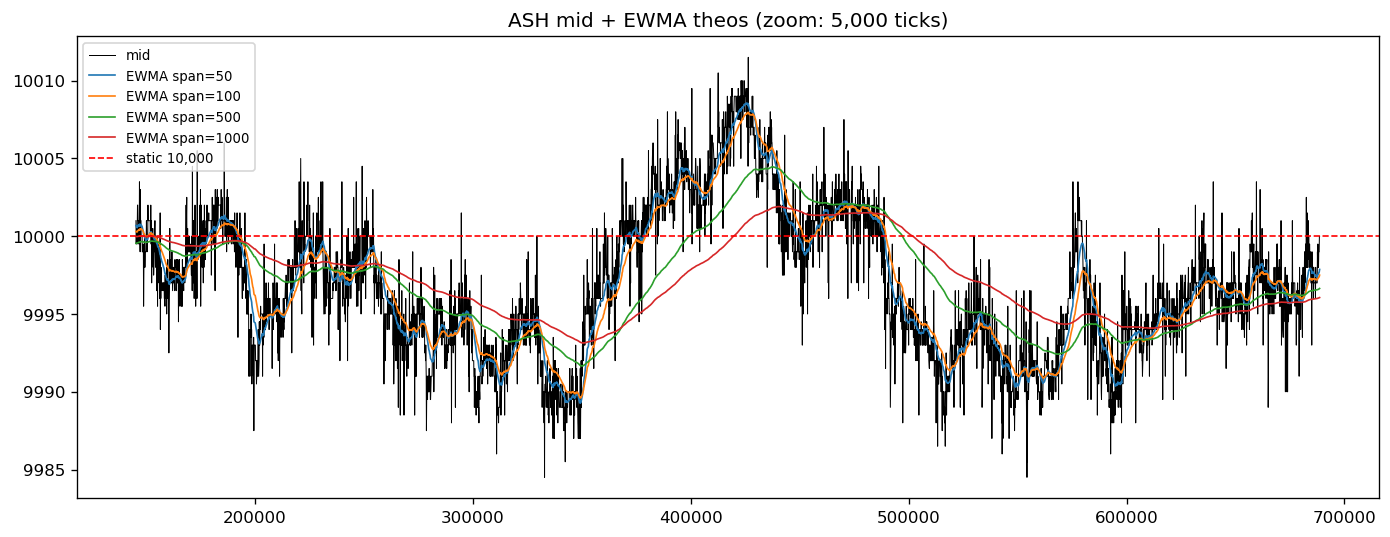

MAE of |mid_{t+H} - theo_t| (lower = better)
     static_10000  ewma_50  ewma_100  ewma_500  ewma_1000
H                                                        
1          3.8587   1.3087    1.5636    2.5377     2.9815
10         3.8596   1.5240    1.7319    2.6133     3.0284
100        3.8571   2.6998    2.7939    3.2097     3.4152


In [67]:
# 1.7 EWMA theos vs static 10,000 — visual + MAE table
spans = [50, 100, 500, 1000]
mid = aco["mid_price"]
ewmas = {s: mid.ewm(span=s, adjust=False).mean() for s in spans}

# Zoomed plot — middle 5,000 ticks
i0 = len(aco) // 2 - 2500 - 10000
i1 = i0 + 5000
fig, ax = plt.subplots()
ax.plot(aco["time"].iloc[i0:i1], mid.iloc[i0:i1], color="black", lw=0.6, label="mid")
for s in spans:
    ax.plot(aco["time"].iloc[i0:i1], ewmas[s].iloc[i0:i1], lw=1, label=f"EWMA span={s}")
ax.axhline(10_000, color="red", lw=1, ls="--", label="static 10,000")
ax.set_title("ASH mid + EWMA theos (zoom: 5,000 ticks)")
ax.legend(loc="upper left", fontsize=8)
plt.show()

# MAE: |mid_{t+H} - theo_t| at H = 1, 10, 100
horizons = [1, 10, 100]
rows = []
for H in horizons:
    future = mid.shift(-H)
    row = {"H": H, "static_10000": (future - 10_000).abs().mean()}
    for s in spans:
        row[f"ewma_{s}"] = (future - ewmas[s]).abs().mean()
    rows.append(row)
mae = pd.DataFrame(rows).set_index("H")
print("MAE of |mid_{t+H} - theo_t| (lower = better)")
print(mae.round(4))

Spread value counts:
spread
5.0       154
6.0       328
7.0       164
8.0        62
9.0       375
10.0      639
11.0      323
12.0      109
13.0      156
15.0       64
16.0    17599
17.0       34
18.0     3452
19.0     3514
20.0        4
21.0      666
22.0        1
Name: count, dtype: int64

Mean spread per day:
day
-2    16.1498
-1    16.1913
 0    16.1845
Name: spread, dtype: float64

Mean spread per intraday bucket (across all days):
intraday_bucket
0    16.1798
1    16.1712
2    16.1615
3    16.2868
4    16.1892
5    16.1545
6    16.2188
7    16.1082
8    16.1767
9    16.1065
Name: spread, dtype: float64

Mean top-of-book depth per day:
     bid_volume_1  ask_volume_1
day                            
-2          14.04         14.18
-1          14.19         14.17
 0          14.18         14.14


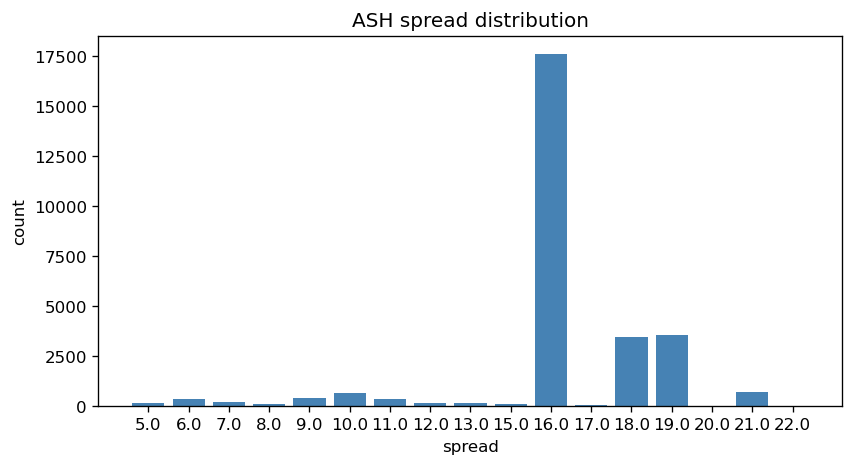

In [68]:
# 1.8 Spread distribution + book depth
spread_counts = aco["spread"].value_counts().sort_index()
print("Spread value counts:")
print(spread_counts)

print("\nMean spread per day:")
print(aco.groupby("day")["spread"].mean().round(4))

aco["intraday_bucket"] = aco["timestamp"] // 100_000  # 10 buckets per day
print("\nMean spread per intraday bucket (across all days):")
print(aco.groupby("intraday_bucket")["spread"].mean().round(4))

print("\nMean top-of-book depth per day:")
print(aco.groupby("day")[["bid_volume_1", "ask_volume_1"]].mean().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(spread_counts.index.astype(str), spread_counts.values, color="steelblue")
ax.set_title("ASH spread distribution")
ax.set_xlabel("spread")
ax.set_ylabel("count")
plt.show()

## 2. PEPPER EDA & Theo

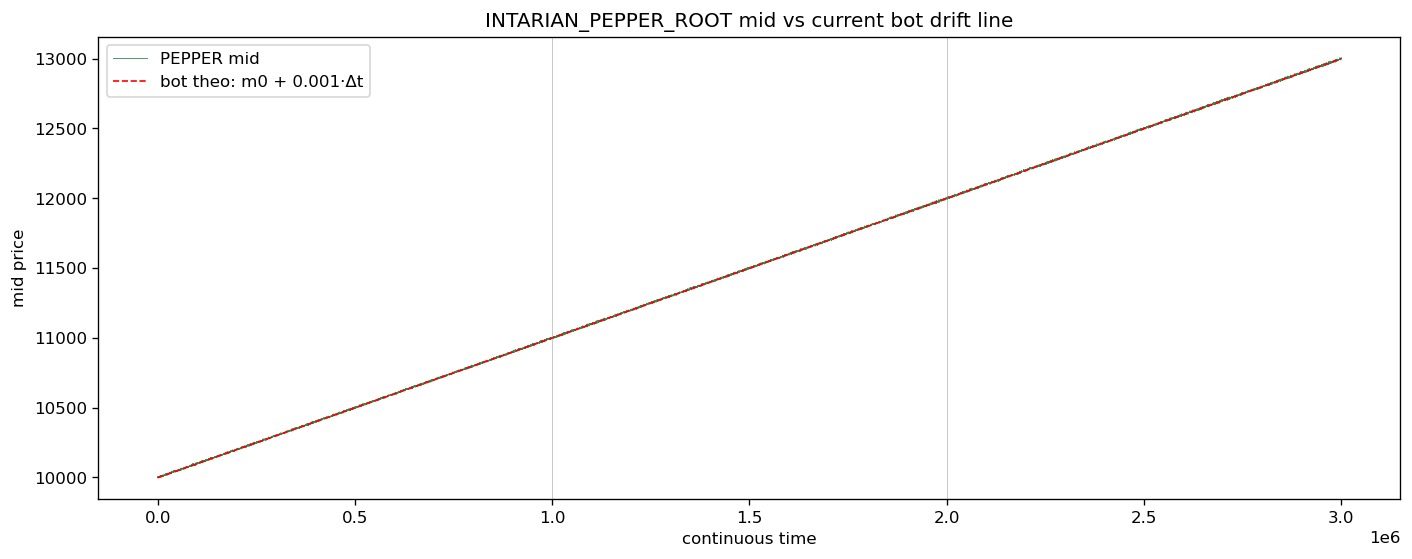

             mean   median         std      min      max  count
day                                                            
-2   10499.963542  10500.0  288.722378   9998.5  11003.0   9984
-1   11500.030051  11500.0  288.669011  10995.0  12006.0   9983
 0   12500.173013  12500.0  288.730986  11994.0  13007.0   9979


In [45]:
# 2.1 Price series with current bot's linear-drift overlay (slope=0.001 in continuous time)
t0 = ipr["time"].iloc[0]
m0 = ipr["mid_price"].iloc[0]
bot_drift = m0 + (ipr["time"] - t0) * 0.001

fig, ax = plt.subplots()
ax.plot(ipr["time"], ipr["mid_price"], lw=0.5, color="seagreen", label="PEPPER mid")
ax.plot(ipr["time"], bot_drift, lw=1, color="red", ls="--", label="bot theo: m0 + 0.001·Δt")
for k in range(1, len(ipr["day"].unique())):
    ax.axvline(k * DAY_LEN, color="gray", lw=0.5, alpha=0.5)
ax.set_title("INTARIAN_PEPPER_ROOT mid vs current bot drift line")
ax.set_xlabel("continuous time")
ax.set_ylabel("mid price")
ax.legend()
plt.show()

per_day = ipr.groupby("day")["mid_price"].agg(["mean", "median", "std", "min", "max", "count"])
print(per_day)

In [51]:
# 2.2 Global linear regression: mid ≈ a + b·time
slope_g, intercept_g, r_g, p_g, se_g = stats.linregress(ipr["time"], ipr["mid_price"])
print(f"Global fit: mid = {intercept_g:.4f} + {slope_g:+.6e} · time")
print(f"  R²: {r_g**2:.4f}")
print(f"  slope stderr: {se_g:.2e}   p-value: {p_g:.2e}")
print(f"  slope per 1M ticks (one day): {slope_g * DAY_LEN:+.3f}")
print(f"  bot's assumed slope (0.001 per tick) = {0.001 * DAY_LEN:+.0f} per day")

Global fit: mid = 9999.9878 + +1.000005e-03 · time
  R²: 1.0000
  slope stderr: 1.47e-08   p-value: 0.00e+00
  slope per 1M ticks (one day): +1000.005
  bot's assumed slope (0.001 per tick) = +1000 per day


In [52]:
# 2.3 Per-day slope — is the drift consistent across days?
rows = []
for d, sub in ipr.groupby("day"):
    s, i, r, p, se = stats.linregress(sub["timestamp"], sub["mid_price"])
    rows.append({"day": d, "intercept": i, "slope_per_tick": s,
                 "slope_per_day": s * DAY_LEN, "r2": r**2, "p": p})
per_day_fit = pd.DataFrame(rows).set_index("day")
print(per_day_fit.round(6))

        intercept  slope_per_tick  slope_per_day        r2    p
day                                                            
-2    9999.979278           0.001    1000.028806  0.999952  0.0
-1   10999.965698           0.001    1000.075813  0.999941  0.0
 0   11999.950821           0.001    1000.079270  0.999933  0.0


ADF on residuals (mid - global_drift):
  statistic : -120.6734
  p-value   : 0.000e+00
  critical  : {'1%': -3.430568403041288, '5%': -2.8616365282341016, '10%': -2.566821379034479}
  ⇒ residuals are stationary (mean-reverting)

AR(1) phi = +0.0084   half-life = 0.15 ticks


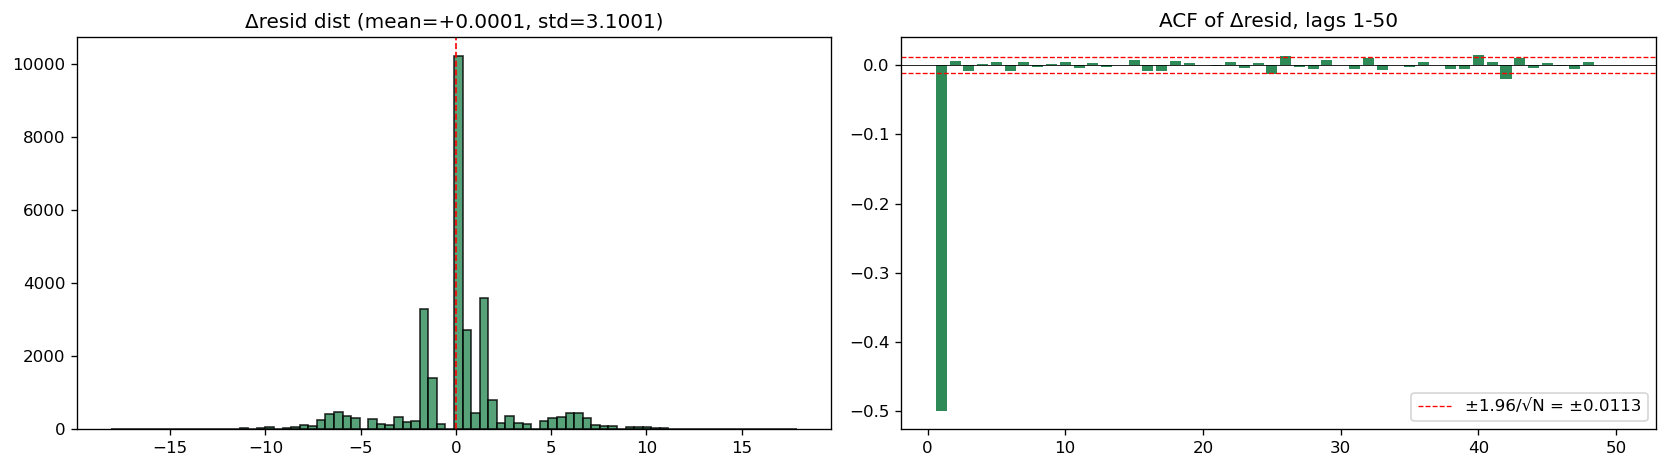

Lag-1 ACF of Δresid: -0.5006


In [53]:
# 2.4 Residuals after global detrending — ADF + ACF
ipr["drift"] = intercept_g + slope_g * ipr["time"]
ipr["resid"] = ipr["mid_price"] - ipr["drift"]

res = ipr["resid"].values
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(res, autolag="AIC")
print(f"ADF on residuals (mid - global_drift):")
print(f"  statistic : {adf_stat:.4f}")
print(f"  p-value   : {adf_p:.3e}")
print(f"  critical  : {adf_crit}")
print("  ⇒ residuals are stationary (mean-reverting)" if adf_p < 0.05 else "  ⇒ residuals NOT stationary at 5%")

# AR(1) half-life on residuals
y, x = res[1:], res[:-1]
phi_ipr, intc = np.polyfit(x, y, 1)
if 0 < phi_ipr < 1:
    hl = -np.log(2) / np.log(phi_ipr)
    print(f"\nAR(1) phi = {phi_ipr:+.4f}   half-life = {hl:.2f} ticks")
else:
    print(f"\nAR(1) phi = {phi_ipr:+.4f}   (no standard half-life)")

# ACF of residual *changes* (what a MM trades on tick-to-tick)
dres = np.diff(res)
n = len(dres); ci = 1.96 / np.sqrt(n)
acf_vals = acf(dres, nlags=50, fft=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(dres, bins=80, color="seagreen", edgecolor="black", alpha=0.8)
axes[0].axvline(0, color="red", lw=1, ls="--")
axes[0].set_title(f"Δresid dist (mean={dres.mean():+.4f}, std={dres.std():.4f})")
lags = np.arange(1, 51)
axes[1].bar(lags, acf_vals[1:], color="seagreen")
axes[1].axhline(ci, color="red", lw=0.8, ls="--", label=f"±1.96/√N = ±{ci:.4f}")
axes[1].axhline(-ci, color="red", lw=0.8, ls="--")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("ACF of Δresid, lags 1-50")
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Lag-1 ACF of Δresid: {acf_vals[1]:+.4f}")

In [56]:
# 2.5 Theo candidates — MAE forecast comparison at horizons 1, 10, 100
horizons = [1, 10, 100]
mid_s = ipr["mid_price"].reset_index(drop=True)

# (a) bot theo: first_mid + 0.001 * (time - t0)  — the current disabled rule
bot_theo = bot_drift.reset_index(drop=True)

# (b) global OLS drift line
global_drift = (intercept_g + slope_g * ipr["time"]).reset_index(drop=True)

# (c) drift + EWMA(residual)  — anchor the level but forecast next-tick resid
ewma_res_50  = ipr["resid"].ewm(span=50,  adjust=False).mean().reset_index(drop=True)
ewma_res_200 = ipr["resid"].ewm(span=200, adjust=False).mean().reset_index(drop=True)

# (d) raw EWMA of mid — no drift
ewma_mid_50  = mid_s.ewm(span=50,  adjust=False).mean()
ewma_mid_200 = mid_s.ewm(span=200, adjust=False).mean()

candidates = {
    "bot_drift_0.001"  : bot_theo,
    "global_drift"     : global_drift,
    "drift+ewma50_res" : global_drift + ewma_res_50,
    "drift+ewma200_res": global_drift + ewma_res_200,
    "ewma50_mid"       : ewma_mid_50,
    "ewma200_mid"      : ewma_mid_200,
    "last_mid"         : mid_s,   # naive baseline
}

rows = []
for H in horizons:
    future = mid_s.shift(-H)
    row = {"H": H}
    for name, theo in candidates.items():
        row[name] = (future - theo).abs().mean()
    rows.append(row)
mae = pd.DataFrame(rows).set_index("H")
print("MAE of |mid_{t+H} - theo_t| for PEPPER (lower = better)")
print(mae.round(4))

MAE of |mid_{t+H} - theo_t| for PEPPER (lower = better)
     bot_drift_0.001  global_drift  drift+ewma50_res  drift+ewma200_res  \
H                                                                         
1             2.0984        1.1548            1.2375             1.1838   
10            2.8872        1.6756            1.6842             1.6811   
100          11.5139       10.0184           10.0197            10.0229   

     ewma50_mid  ewma200_mid  last_mid  
H                                       
1        2.9365      10.0401    1.8809  
10       3.7427      10.9411    2.2669  
100     12.4716      19.9571   10.0329  


PEPPER spread value counts:
spread
2.0      282
3.0      373
4.0      138
5.0       49
6.0       57
7.0       66
8.0      141
9.0      128
10.0      67
11.0    3069
12.0    6138
13.0    6355
14.0    4752
15.0    1895
16.0    2058
17.0    1574
18.0     219
19.0     171
20.0     133
21.0      23
Name: count, dtype: int64

Mean spread per day:
day
-2    11.995
-1    13.012
 0    14.129
Name: spread, dtype: float64

Mean top-of-book depth per day:
     bid_volume_1  ask_volume_1
day                            
-2          11.53         11.52
-1          11.53         11.51
 0          11.57         11.53


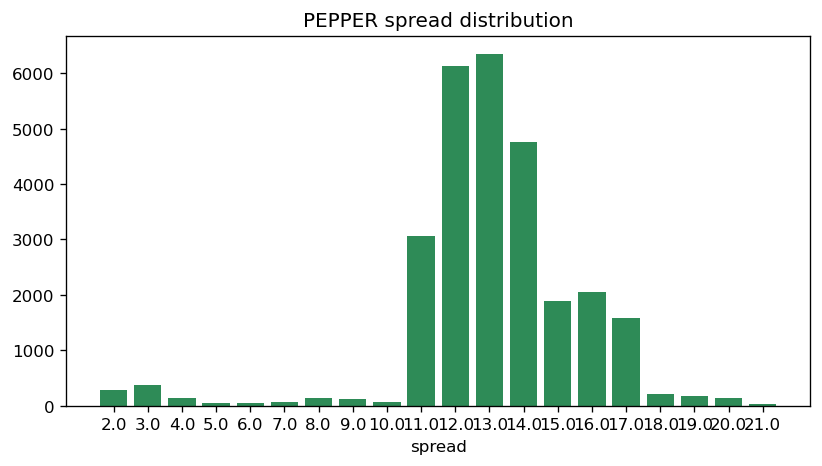

In [58]:
# 2.6 Spread / depth — is PEPPER quotable?
spread_counts = ipr["spread"].value_counts().sort_index()
print("PEPPER spread value counts:")
print(spread_counts)
print(f"\nMean spread per day:\n{ipr.groupby('day')['spread'].mean().round(3)}")
print(f"\nMean top-of-book depth per day:\n{ipr.groupby('day')[['bid_volume_1', 'ask_volume_1']].mean().round(2)}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(spread_counts.index.astype(str), spread_counts.values, color="seagreen")
ax.set_title("PEPPER spread distribution")
ax.set_xlabel("spread")
plt.show()